# Anomaly Investigation: Refund Anomaly (psp_beta)

Standalone notebook — reloads and prepares the data independently of `01_eda.ipynb`.

Checking whether refunded amounts are consistent with the original transaction amount.


In [1]:
import pandas as pd

df = pd.read_csv('/home/veronika/Anomaly_Hunter_Solidgate/hackathon_int20h_dataset_test.csv')

In [2]:
df['created_at'] = pd.to_datetime(df['created_at'])
df['processed_at'] = pd.to_datetime(df['processed_at'])

In [3]:
import matplotlib.pyplot as plt

In [4]:
import seaborn as sns

In [5]:
df['week'] = df['created_at'].dt.to_period('W').astype(str)

## 10. Refund anomaly investigation

Checking whether refunded amounts are consistent with the original transaction amount. `amount` and `refunded_amount` are stored in each transaction's local currency (7 currencies in this dataset with very different numeric scales, e.g. UAH vs USD) - **summing raw values across rows of different currencies is not meaningful** unless the currency mix is checked or held constant. This point is revisited below after a first pass gave a misleading result.

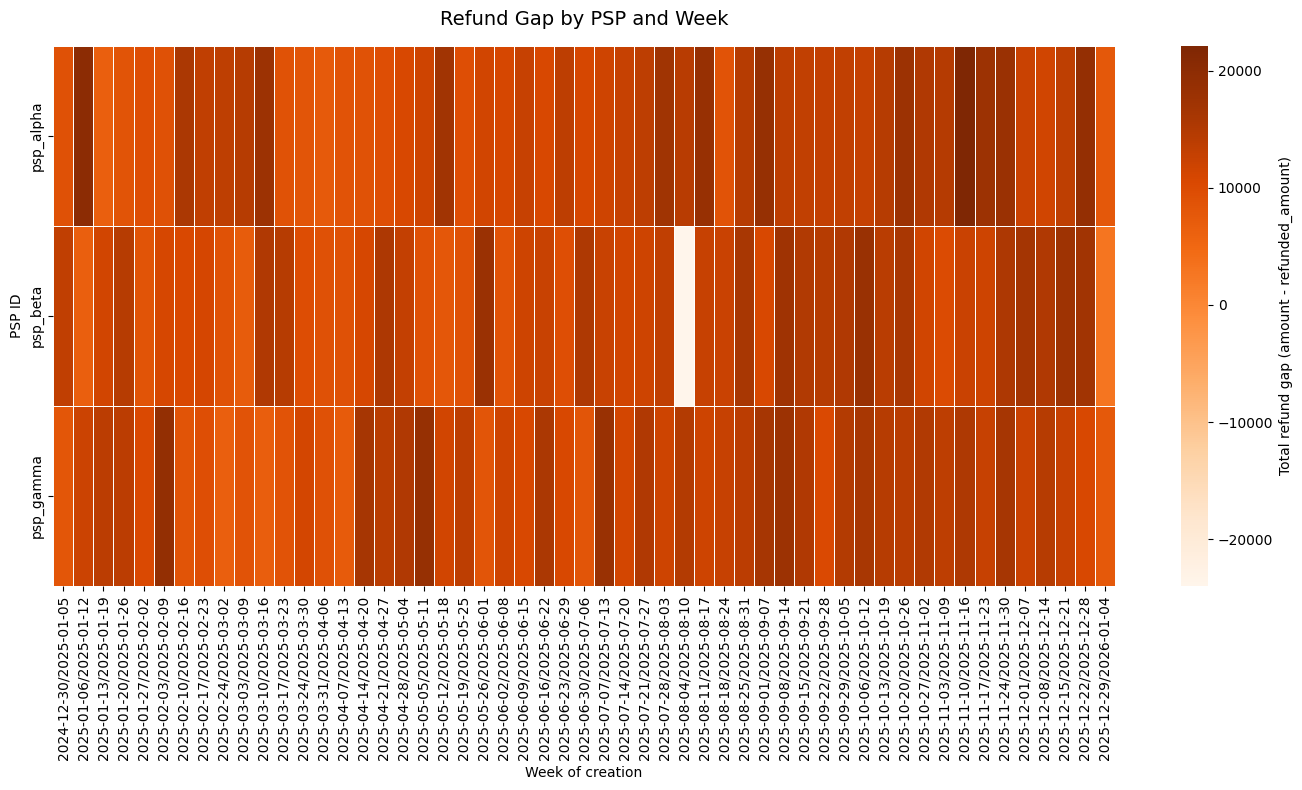

In [6]:
refunds_df = df[df['has_refund'] == True].copy()
refunds_df['refund_gap'] = refunds_df['amount'] - refunds_df['refunded_amount']

pivot_refund = refunds_df.pivot_table(values='refund_gap', index='psp_id', columns='week', aggfunc='sum')

plt.figure(figsize=(14, 8))
sns.heatmap(
    pivot_refund,
    cmap="Oranges",
    linewidths=0.5,
    cbar_kws={'label': 'Total refund gap (amount - refunded_amount)'}
)
plt.title('Refund Gap by PSP and Week', fontsize=14, pad=15)
plt.xlabel('Week of creation')
plt.ylabel('PSP ID')
plt.tight_layout()
plt.show()

One week stands out for `psp_beta` with a **negative** total gap - meaning refunded amounts exceeded charged amounts in aggregate. Before trusting this: a currency-mix check (below) confirmed the currency composition of this window is essentially identical to the yearly baseline for every PSP, so the negative sum is not a currency-mixing artifact. Zooming into the window in daily detail:

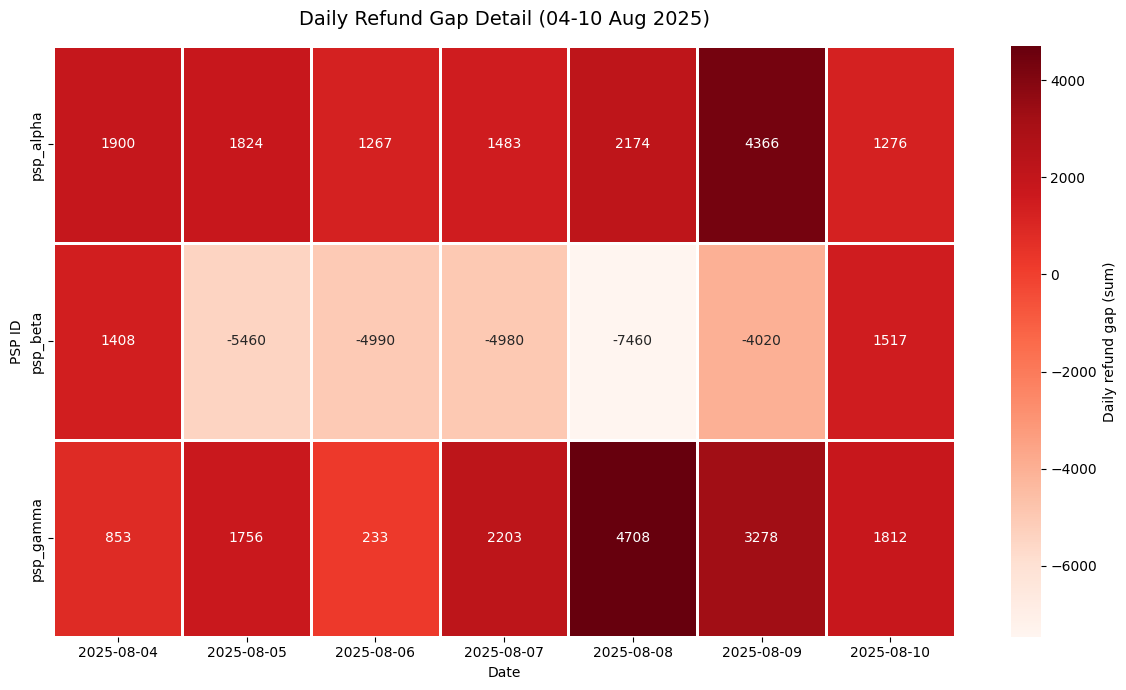

In [7]:
refunds_df['created_date'] = refunds_df['created_at'].dt.date

start_target = pd.to_datetime('2025-08-04').date()
end_target = pd.to_datetime('2025-08-10').date()

weekly_detail = refunds_df[
    (refunds_df['created_date'] >= start_target) &
    (refunds_df['created_date'] <= end_target)
].copy()

pivot_daily = weekly_detail.pivot_table(
    values='refund_gap', index='psp_id', columns='created_date', aggfunc='sum'
).fillna(0)

plt.figure(figsize=(12, 7))
sns.heatmap(
    pivot_daily,
    annot=True,
    fmt=".0f",
    cmap="Reds",
    linewidths=0.8,
    cbar_kws={'label': 'Daily refund gap (sum)'}
)
plt.title('Daily Refund Gap Detail (04-10 Aug 2025)', fontsize=14, pad=15)
plt.xlabel('Date')
plt.ylabel('PSP ID')
plt.tight_layout()
plt.show()

**Negative gap = over-refund.** `psp_beta` is negative on 5-9 August specifically (4 and 10 August are normal and positive, like every other provider on every other day). This isolates the window precisely.

In [8]:
beta_august_window = df[
    (df['psp_id'] == 'psp_beta') &
    (df['created_at'] >= '2025-08-05') &
    (df['created_at'] <= '2025-08-09 23:59:59')
]

count_window = beta_august_window.shape[0]
count_total_year = df[df['psp_id'] == 'psp_beta'].shape[0]
share = (count_window / count_total_year) * 100 if count_total_year > 0 else 0

print("=== PSP_BETA WINDOW ANALYSIS (05-09 Aug 2025) ===")
print(f"Transactions in the window:   {count_window}")
print(f"Total transactions this year: {count_total_year}")
print(f"Share of the yearly total:    {share:.4f}%")
print("==================================================")

=== PSP_BETA WINDOW ANALYSIS (05-09 Aug 2025) ===
Transactions in the window:   4943
Total transactions this year: 333027
Share of the yearly total:    1.4843%


In [9]:
start_window = '2025-08-05'
end_window = '2025-08-09 23:59:59'

df_window = df[(df['created_at'] >= start_window) & (df['created_at'] <= end_window)]
window_counts = df_window.groupby(['psp_id', 'currency']).size().reset_index(name='tx_count')
window_counts['share_%'] = (window_counts['tx_count'] / window_counts.groupby('psp_id')['tx_count'].transform('sum')) * 100

df_year = df[(df['created_at'] >= '2025-01-01') & (df['created_at'] <= '2025-12-31 23:59:59')]
year_counts = df_year.groupby(['psp_id', 'currency']).size().reset_index(name='tx_count')
year_counts['share_%'] = (year_counts['tx_count'] / year_counts.groupby('psp_id')['tx_count'].transform('sum')) * 100

print("=== CURRENCY MIX IN THE WINDOW (05-09 Aug) ===")
print(window_counts.sort_values(by=['psp_id', 'share_%'], ascending=[True, False]).to_string(index=False))

print("\n=== CURRENCY MIX FOR THE FULL YEAR (2025) ===")
print(year_counts.sort_values(by=['psp_id', 'share_%'], ascending=[True, False]).to_string(index=False))

=== CURRENCY MIX IN THE WINDOW (05-09 Aug) ===
   psp_id currency  tx_count   share_%
psp_alpha      USD      2479 49.186508
psp_alpha      CAD       786 15.595238
psp_alpha      EUR       606 12.023810
psp_alpha      PLN       330  6.547619
psp_alpha      GBP       302  5.992063
psp_alpha      UAH       271  5.376984
psp_alpha      MXN       266  5.277778
 psp_beta      USD      2475 50.070807
 psp_beta      CAD       740 14.970666
 psp_beta      EUR       600 12.138378
 psp_beta      UAH       302  6.109650
 psp_beta      PLN       297  6.008497
 psp_beta      GBP       276  5.583654
 psp_beta      MXN       253  5.118349
psp_gamma      USD      2554 50.265696
psp_gamma      CAD       764 15.036410
psp_gamma      EUR       642 12.635308
psp_gamma      UAH       324  6.376698
psp_gamma      GBP       291  5.727219
psp_gamma      PLN       287  5.648494
psp_gamma      MXN       219  4.310175

=== CURRENCY MIX FOR THE FULL YEAR (2025) ===
   psp_id currency  tx_count   share_%
psp_alpha

**Currency-mix hypothesis ruled out:** the distribution is essentially identical between the window and the full year for every provider - the negative gap is not an artifact of a shifted currency mix. Moving from aggregate sums to a per-row check, which is valid regardless of currency (both `amount` and `refunded_amount` share the same currency within a single row):

In [10]:
df['individual_gap'] = df['refunded_amount'] - df['amount']
is_broken_tx = df['individual_gap'] > 0

start_window = '2025-08-05'
end_window = '2025-08-09 23:59:59'

window_broken = df[is_broken_tx & (df['created_at'] >= start_window) & (df['created_at'] <= end_window)]
window_count = window_broken.shape[0]
window_sum = window_broken['individual_gap'].sum()

year_broken = df[is_broken_tx & (df['created_at'] >= '2025-01-01') & (df['created_at'] <= '2025-12-31 23:59:59')]
year_count = year_broken.shape[0]
year_sum = year_broken['individual_gap'].sum()

print("=== OVER-REFUNDED TRANSACTIONS (refunded_amount > amount) ===")
print("In the 05-09 August window:")
print(f"  Count:        {window_count}")
print(f"  Excess total: {window_sum:,.2f}")
print("\nFull year (2025):")
print(f"  Count:        {year_count}")
print(f"  Excess total: {year_sum:,.2f}")
print("===============================================================")

if window_count > 0:
    print("\nTop 5 most severe cases in the August window:")
    cols_to_show = ['created_at', 'psp_id', 'currency', 'amount', 'refunded_amount', 'individual_gap']
    print(window_broken[cols_to_show].sort_values(by='individual_gap', ascending=False).head(5).to_string(index=False))

=== OVER-REFUNDED TRANSACTIONS (refunded_amount > amount) ===
In the 05-09 August window:
  Count:        2691
  Excess total: 26,910.00

Full year (2025):
  Count:        2691
  Excess total: 26,910.00

Top 5 most severe cases in the August window:
         created_at   psp_id currency  amount  refunded_amount  individual_gap
2025-08-09 07:40:59 psp_beta      GBP    62.4             72.4            10.0
2025-08-06 15:10:00 psp_beta      GBP    62.4             72.4            10.0
2025-08-07 21:42:20 psp_beta      GBP    62.4             72.4            10.0
2025-08-09 15:47:31 psp_beta      GBP    62.4             72.4            10.0
2025-08-09 02:54:48 psp_beta      GBP    62.4             72.4            10.0


**100% of over-refunded transactions for the entire year fall inside this 5-day window** - window count equals year count exactly. This is an even cleaner concentration than the psp_gamma incident.

In [11]:
print("=" * 70)
print(f"ANOMALY CHECKLIST ({window_broken.shape[0]} rows)")
print("=" * 70)

nunique_gaps = window_broken['individual_gap'].round(2).nunique()
print(f"1. Unique gap values (rounded to 2dp): {nunique_gaps}")
if nunique_gaps == 1:
    exact_value = window_broken['individual_gap'].iloc[0]
    print(f"   Every single row has the same gap: {exact_value} units.")
else:
    print("   Most common gap values:")
    print(window_broken['individual_gap'].value_counts().head(5))

print("\n2. Currency mix among over-refunded transactions:")
print(window_broken['currency'].value_counts())
print("\n   Median gap per currency:")
print(window_broken.groupby('currency')['individual_gap'].median())

print("\n3. PSP breakdown:")
print(window_broken['psp_id'].value_counts())

print("\n4. Standard profile:")
print(f"   status values:     {window_broken['status'].unique()}")
print(f"   has_refund values: {window_broken['has_refund'].unique()}")
print("\n   Top 5 banks involved:")
print(window_broken['bank_id'].value_counts().head(5))

total_orders = window_broken.shape[0]
unique_orders = window_broken['order_id'].nunique()
print(f"\n   Total rows: {total_orders} | Unique order_id: {unique_orders}")

ANOMALY CHECKLIST (2691 rows)
1. Unique gap values (rounded to 2dp): 1
   Every single row has the same gap: 10.0 units.

2. Currency mix among over-refunded transactions:
currency
USD    1350
CAD     396
EUR     337
PLN     174
UAH     170
GBP     138
MXN     126
Name: count, dtype: int64

   Median gap per currency:
currency
CAD    10.0
EUR    10.0
GBP    10.0
MXN    10.0
PLN    10.0
UAH    10.0
USD    10.0
Name: individual_gap, dtype: float64

3. PSP breakdown:
psp_id
psp_beta    2691
Name: count, dtype: int64

4. Standard profile:
   status values:     ['success' 'fail']
   has_refund values: [ True]

   Top 5 banks involved:
bank_id
17    75
3     70
38    69
23    67
39    65
Name: count, dtype: int64

   Total rows: 2691 | Unique order_id: 2691


1. Transactions with status == 'fail' among the over-refunded: 66
   Contradiction: a failed transaction cannot have a real refund.
   Min refunded_amount for these:  21.7
   Max refunded_amount for these:  2070.0
   Share of failed among anomalous: 2.45%

2. order_id range for anomalous rows:
   Min: 58 | Max: 998905 | Unique: 2691 (of 2691 rows)

3. Time distribution:


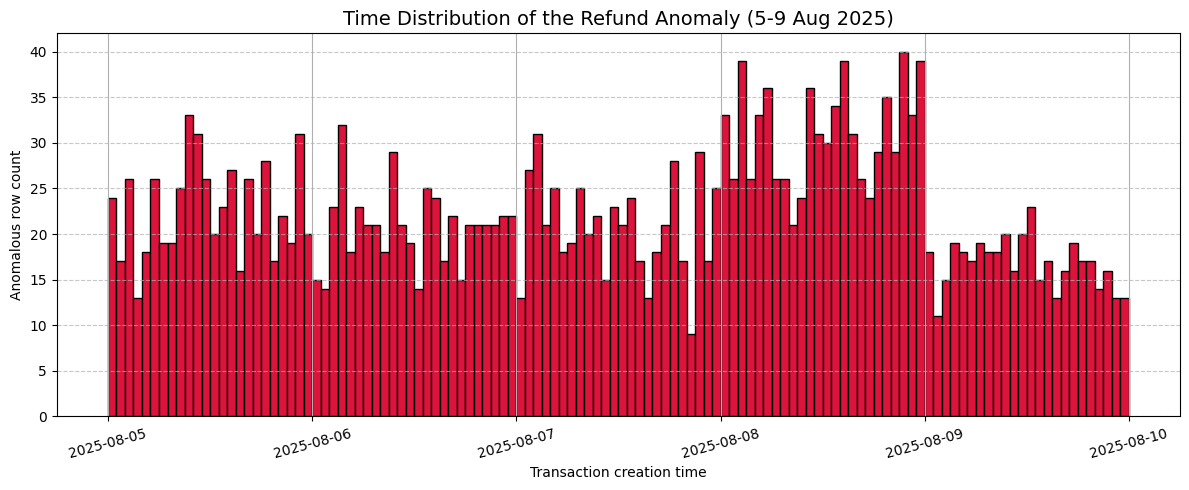

In [12]:
fails_in_anomaly = window_broken[window_broken['status'] == 'fail']
count_fails = fails_in_anomaly.shape[0]

print(f"1. Transactions with status == 'fail' among the over-refunded: {count_fails}")
if count_fails > 0:
    print("   Contradiction: a failed transaction cannot have a real refund.")
    print(f"   Min refunded_amount for these:  {fails_in_anomaly['refunded_amount'].min()}")
    print(f"   Max refunded_amount for these:  {fails_in_anomaly['refunded_amount'].max()}")
    print(f"   Share of failed among anomalous: {count_fails / window_broken.shape[0] * 100:.2f}%")
else:
    print("   All anomalous transactions have status == success.")

min_order = window_broken['order_id'].min()
max_order = window_broken['order_id'].max()
unique_orders = window_broken['order_id'].nunique()
print(f"\n2. order_id range for anomalous rows:")
print(f"   Min: {min_order} | Max: {max_order} | Unique: {unique_orders} (of {window_broken.shape[0]} rows)")

print("\n3. Time distribution:")
plt.figure(figsize=(12, 5))
window_broken['created_at'].hist(bins=120, edgecolor='black', color='crimson')
plt.title('Time Distribution of the Refund Anomaly (5-9 Aug 2025)', fontsize=14)
plt.xlabel('Transaction creation time')
plt.ylabel('Anomalous row count')
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Findings:**
- gap is a flat **+10 for every currency** (median gap = 10.0 in USD, EUR, UAH, GBP, CAD, PLN, MXN alike) - a real business rule would never add the same absolute amount regardless of currency; this is a strong artificial-injection signature;
- 100% of these transactions belong to `psp_beta`;
- 66 rows (2.45%) have `status == fail` while still carrying a positive `refunded_amount` - a logical impossibility, since a failed payment cannot be refunded, and further evidence that this cluster is corrupted/inserted rather than a natural business pattern;
- `order_id` spans nearly the full dataset range (58 to 998,905) - unlike `bank_id == 777`, this is not diagnostic on its own, since `order_id` does not correlate with `created_at` anywhere in this dataset (established in section 3);
- the time distribution is bounded sharply by the window edges (0 rows outside 5-9 August), with day/night oscillation reflecting normal transaction volume rather than a gradually intensifying incident.